In [1]:
import pandas as pd

data = pd.read_csv('google_max_30.csv')

# Affichage des premières lignes pour avoir un aperçu
data.head()


,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
0,4.1,159.0,19000000.0,4.00000,0.0,1.515283e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3.9,967.0,14000000.0,5.69897,0.0,1.515974e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4.7,87510.0,8700000.0,6.69897,0.0,1.533082e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.5,215644.0,25000000.0,7.69897,0.0,1.528416e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4.3,967.0,2800000.0,5.00000,0.0,1.529453e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


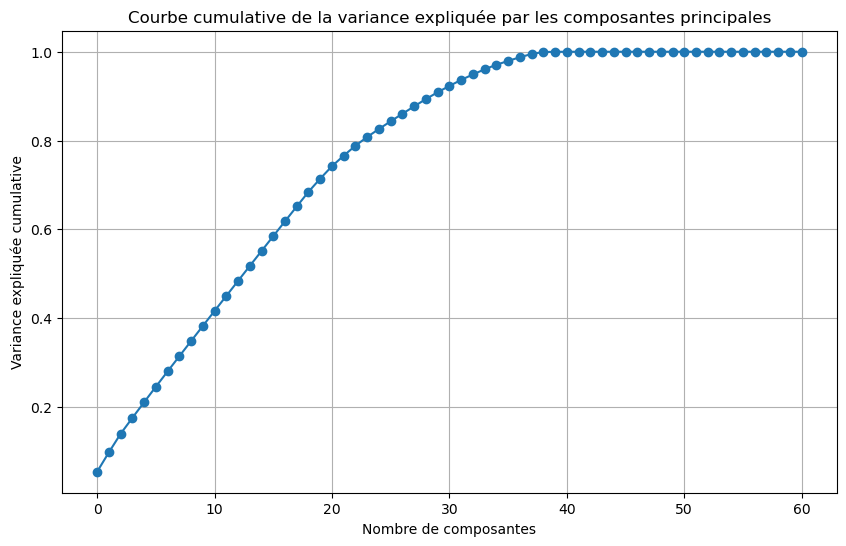

array([0.0542659 , 0.09787274, 0.13966441, 0.17546951, 0.21068439,
       0.24563161, 0.28009447, 0.31432876, 0.34843159, 0.38241701,
       0.41629668, 0.4501121 , 0.48388628, 0.51761017, 0.55126723,
       0.58478142, 0.6182285 , 0.65149539, 0.68459573, 0.7142109 ,
       0.74223278, 0.76601848, 0.78836915, 0.80809098, 0.82600726,
       0.8433852 , 0.86033627, 0.87702751, 0.89336057, 0.9088054 ,
       0.92293544, 0.93655325, 0.94875885, 0.96043192, 0.97067021,
       0.97921861, 0.98761235, 0.99482266, 0.99936693, 0.99983798,
       0.99991279, 0.99996756, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Exclure la variable 'Rating' et normaliser les autres variables
features = data.drop('Rating', axis=1)
features_scaled = StandardScaler().fit_transform(features)

# Effectuer l'ACP
pca = PCA()
principalComponents = pca.fit_transform(features_scaled)

# Calculer la variance expliquée cumulative
variance_explained_cumulative = pca.explained_variance_ratio_.cumsum()

# Tracer la courbe cumulative de la variance expliquée
plt.figure(figsize=(10, 6))
plt.plot(variance_explained_cumulative, marker='o')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulative')
plt.title('Courbe cumulative de la variance expliquée par les composantes principales')
plt.grid(True)
plt.show()

# Afficher également les valeurs numériques de la variance expliquée cumulative
variance_explained_cumulative


In [3]:
import seaborn as sns

# Créer un DataFrame avec les scores des deux premières composantes principales et les ratings
pca_df = pd.DataFrame(data = principalComponents[:, :2], columns = ['PC1', 'PC2'])
pca_df['Rating'] = data['Rating']


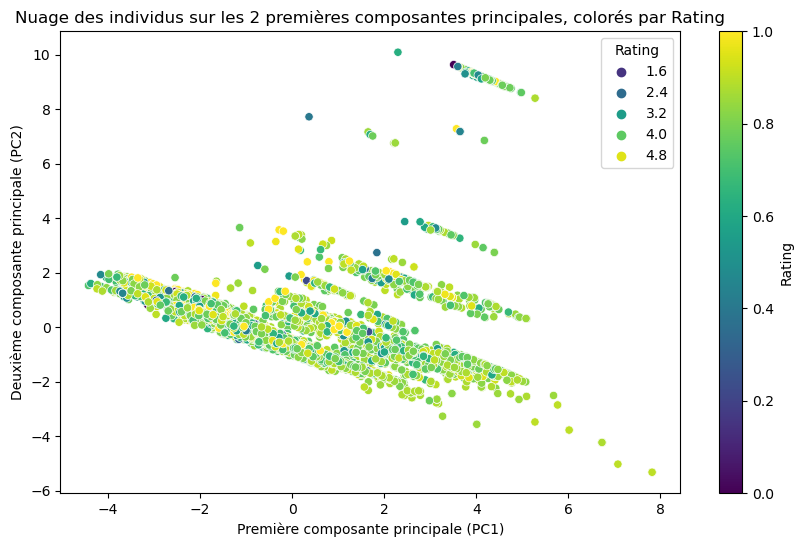

In [4]:
# Corriger l'erreur et tracer à nouveau le nuage des points
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(x='PC1', y='PC2', hue='Rating', palette='viridis', data=pca_df)
plt.title('Nuage des individus sur les 2 premières composantes principales, colorés par Rating')
plt.xlabel('Première composante principale (PC1)')
plt.ylabel('Deuxième composante principale (PC2)')

# Ajouter une barre de couleur pour les ratings
plt.colorbar(scatter.collections[0], label='Rating')
plt.show()


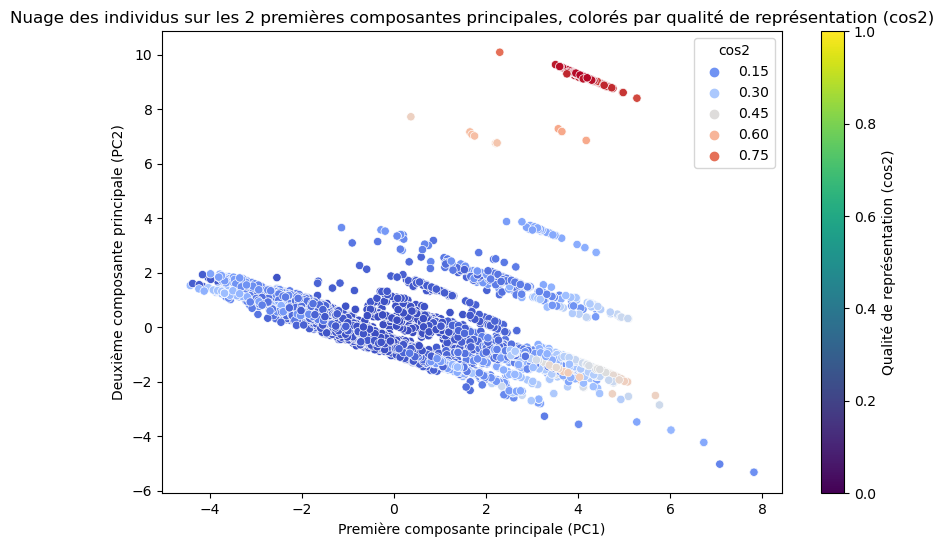

In [5]:
import numpy as np

# Réaliser à nouveau le calcul du cos2 pour chaque individu sur les deux premières composantes
cos2_PC1 = (principalComponents[:, 0] ** 2) / np.sum(principalComponents ** 2, axis=1)
cos2_PC2 = (principalComponents[:, 1] ** 2) / np.sum(principalComponents ** 2, axis=1)
cos2_sum = cos2_PC1 + cos2_PC2

# Ajouter les valeurs de cos2 au DataFrame
pca_df['cos2'] = cos2_sum

# Tracer le nuage des points colorés selon la qualité de la représentation (cos2)
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(x='PC1', y='PC2', hue='cos2', palette='coolwarm', data=pca_df)
plt.title('Nuage des individus sur les 2 premières composantes principales, colorés par qualité de représentation (cos2)')
plt.xlabel('Première composante principale (PC1)')
plt.ylabel('Deuxième composante principale (PC2)')

# Ajouter une barre de couleur pour le cos2
plt.colorbar(scatter.collections[0], label='Qualité de représentation (cos2)')
plt.show()


In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Création de la variable cible "target"
def categorize_rating(rating):
    if rating < 4.1:
        return 'Low' #low
    elif rating <= 4.4:
        return 'Medium' #Medium
    else:
        return 'High' #high

data['target'] = data['Rating'].apply(categorize_rating)
target = data['target'] 
count_target=data['target'].value_counts()
print (target)
count_target


0       Medium
1          Low
2         High
3         High
4       Medium
         ...  
7718      High
7719       Low
7720      High
7721      High
7722      High
Name: target, Length: 7723, dtype: object


Medium    2984
High      2459
Low       2280
Name: target, dtype: int64

In [28]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Création de la variable cible 'target'
data['target'] = pd.cut(data['Rating'], bins=[0, 4.1, 4.4, 5], labels=['<4.1', '4.1-4.4', '>4.4'], include_lowest=True)

# Préparation des données pour l'AFD
X_afd = features_scaled  # Utiliser les mêmes features que pour l'ACP, déjà normalisées
y_afd = data['target']

# Appliquer l'AFD
lda = LDA()
X_lda = lda.fit_transform(X_afd, y_afd)

# Nombre d'axes factoriels obtenus
nombre_axes = X_lda.shape[1]
nombre_axes


2

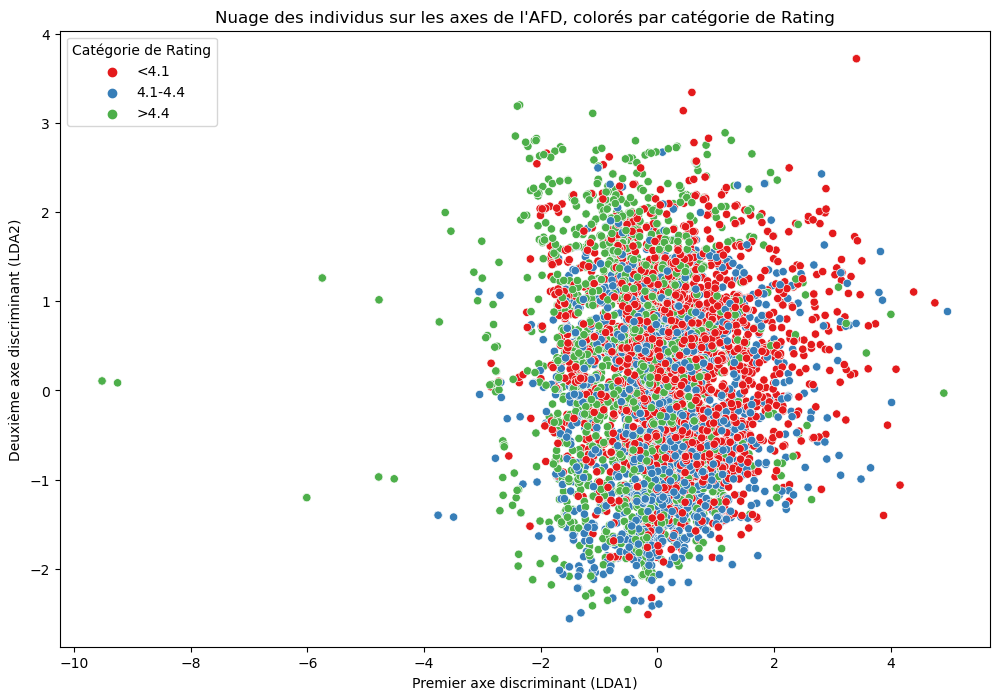

In [29]:
# Créer un DataFrame pour les résultats de l'AFD
lda_df = pd.DataFrame(data=X_lda, columns=['LDA1', 'LDA2'])
lda_df['target'] = y_afd

# Tracer le nuage des points colorés selon la variable 'target'
plt.figure(figsize=(12, 8))
sns.scatterplot(x='LDA1', y='LDA2', hue='target', palette='Set1', data=lda_df)
plt.title('Nuage des individus sur les axes de l\'AFD, colorés par catégorie de Rating')
plt.xlabel('Premier axe discriminant (LDA1)')
plt.ylabel('Deuxième axe discriminant (LDA2)')
plt.legend(title='Catégorie de Rating')
plt.show()


Complexité Intrinsèque des Données : Les Ratings des applications sur le Google Play Store sont influencés par de nombreux facteurs, tels que la qualité de l'application, les fonctionnalités, les préférences des utilisateurs, les mises à jour, etc. Cette complexité peut rendre difficile la séparation nette des classes basées uniquement sur les variables disponibles.

Chevauchement des Caractéristiques : Il est possible que les applications de différentes catégories de Ratings partagent des caractéristiques similaires. Par exemple, des applications avec des Ratings élevés et moyens pourraient avoir des nombres de téléchargements ou des caractéristiques de genre similaires, rendant difficile leur distinction.

Limitation des Deux Axes Discriminants : L'AFD dans ce cas est limitée à deux axes discriminants en raison du nombre de classes cibles. Ces deux axes peuvent ne pas capturer suffisamment la variabilité nécessaire pour séparer complètement les classes. Des informations importantes pour la discrimination pourraient être contenues dans d'autres dimensions non capturées par ces deux axes.

Variabilité au sein des Classes : Il peut y avoir une variabilité significative au sein même des classes de Ratings. Par exemple, deux applications avec des Ratings similaires pourraient différer considérablement en termes de fonctionnalités ou de public cible, ce qui complique la tâche de trouver des axes qui les séparent nettement des autres classes.

Qualité des Données : Si les données contiennent des erreurs, des valeurs manquantes ou des incohérences, cela peut affecter la capacité de l'AFD à discriminer efficacement entre les classes.

Pour améliorer la séparation, on pourrait envisager d'explorer des techniques d'analyse supplémentaires, d'inclure d'autres variables pertinentes, ou d'utiliser des méthodes de classification plus avancées qui peuvent gérer la complexité et les chevauchements de manière plus efficace.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Diviser les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_afd, y_afd, test_size=0.3, random_state=42)

# Entraîner le modèle AFD sur l'ensemble d'entraînement
lda_classifier = LDA()
lda_classifier.fit(X_train, y_train)

# Prédire les classes sur l'ensemble de test
y_pred = lda_classifier.predict(X_test)

# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)

# Construire la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

accuracy, conf_matrix


(0.44540353905912816,
 array([[279, 323, 136],
        [185, 490, 173],
        [218, 250, 263]], dtype=int64))

L'accuracy de 44.54% indique que moins de la moitié des prédictions étaient correctes. Cela suggère que le modèle a des difficultés à classifier correctement les applications selon les catégories de Ratings.

Dans la matrice de confusion, les valeurs sur la diagonale représentent les prédictions correctes pour chaque catégorie. Les autres valeurs indiquent les erreurs de classification. Par exemple, 279 applications avec un vrai Rating de "<4.1" ont été correctement classées, tandis que 323 ont été incorrectement classées comme "4.1-4.4" et 136 comme ">4.4".

En conclusion, bien que l'AFD ait pu identifier des axes discriminants, la précision globale de la classification n'est pas très élevée, et il y a un nombre significatif d'erreurs de classification. Cela peut être dû à la complexité des données, à l'overlap entre les classes de Ratings, ou à la nécessité d'utiliser des méthodes de classification plus sophistiquées et possiblement d'autres variables explicatives pour améliorer la performance de la classificatio

In [32]:
from sklearn.svm import LinearSVR

# Préparer les caractéristiques (features) et la cible (target)
X_svm = features_scaled  # Caractéristiques déjà normalisées
y_svm = data['Rating']

# Créer et entraîner le modèle LinearSVR
svm_model = LinearSVR(dual= True,random_state=42, max_iter=10000)
svm_model.fit(X_svm, y_svm)

# Afficher les paramètres du modèle entraîné pour confirmation
svm_model.get_params()





C:\ProgramData\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'C': 1.0,
 'dual': True,
 'epsilon': 0.0,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'loss': 'epsilon_insensitive',
 'max_iter': 10000,
 'random_state': 42,
 'tol': 0.0001,
 'verbose': 0}

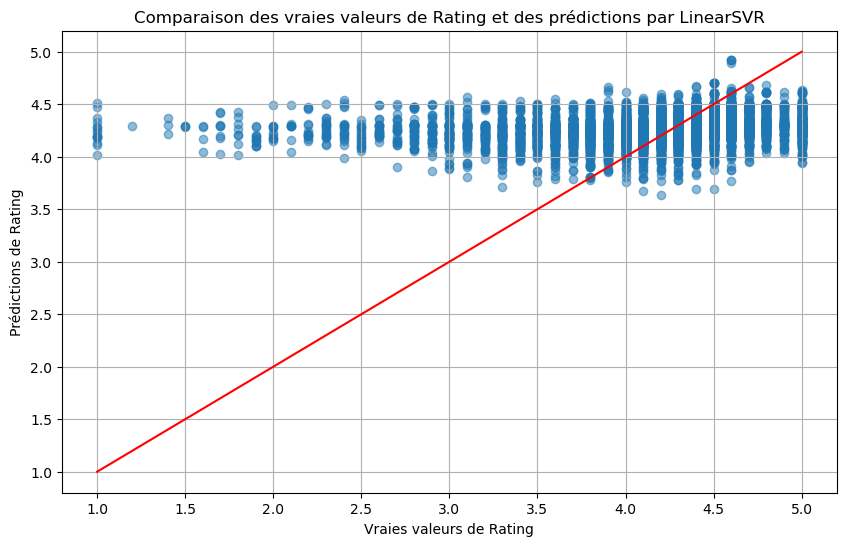

0.22194176215472208

In [33]:
# Générer les prédictions du modèle
y_pred_svm = svm_model.predict(X_svm)

# Calculer la corrélation entre les prédictions et les vraies valeurs
correlation = np.corrcoef(y_svm, y_pred_svm)[0, 1]

# Tracer le scatterplot comparant les prédictions et les vraies valeurs
plt.figure(figsize=(10, 6))
plt.scatter(y_svm, y_pred_svm, alpha=0.5)
plt.xlabel('Vraies valeurs de Rating')
plt.ylabel('Prédictions de Rating')
plt.title('Comparaison des vraies valeurs de Rating et des prédictions par LinearSVR')
plt.plot([min(y_svm), max(y_svm)], [min(y_svm), max(y_svm)], color='red')  # ligne y=x pour référence
plt.grid(True)
plt.show()

correlation


La corrélation entre les prédictions du modèle LinearSVR et les vraies valeurs de Rating est d'environ 0.222. Cette corrélation, bien que positive, est relativement faible, indiquant que la relation entre les prédictions du modèle et les vraies valeurs de Rating n'est pas très forte.

Le scatterplot montre également cette relation. Les points sont dispersés autour de la ligne rouge (qui représente une correspondance parfaite entre les prédictions et les vraies valeurs). Une dispersion importante autour de cette ligne indique une précision limitée dans les prédictions du modèle.

En conclusion, le modèle LinearSVR semble avoir une capacité limitée à prédire avec précision les Ratings des applications sur le Google Play Store dans cet ensemble de données. Cela peut être dû à la complexité des facteurs influençant les Ratings, ou à la nécessité d'utiliser un modèle plus sophistiqué ou d'ajuster davantage les paramètres du modèle actuel.

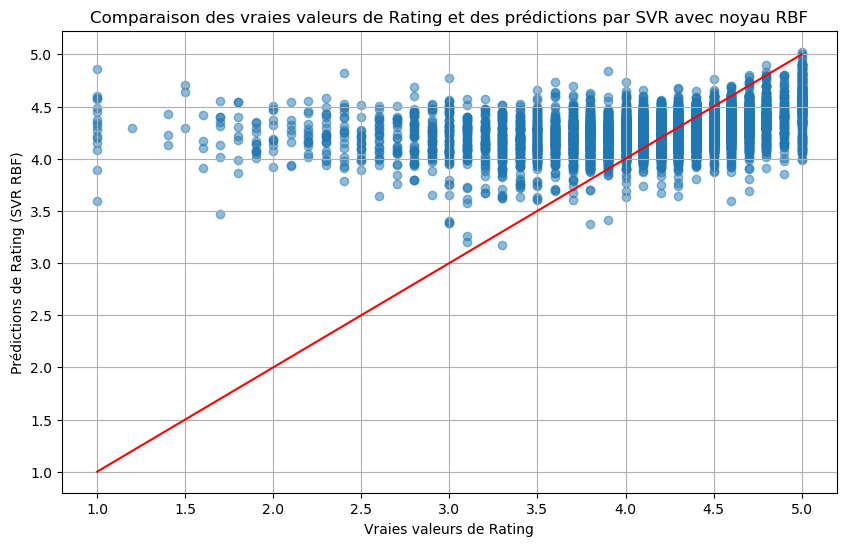

0.34277329842848475

In [34]:
from sklearn.svm import SVR

# Créer et entraîner le modèle SVR avec noyau RBF
svm_rbf_model = SVR(kernel='rbf')
svm_rbf_model.fit(X_svm, y_svm)

# Générer les prédictions du modèle SVR avec noyau RBF
y_pred_svm_rbf = svm_rbf_model.predict(X_svm)

# Calculer la corrélation entre les prédictions et les vraies valeurs pour le modèle SVR avec noyau RBF
correlation_rbf = np.corrcoef(y_svm, y_pred_svm_rbf)[0, 1]

# Tracer le scatterplot comparant les prédictions et les vraies valeurs pour le modèle SVR avec noyau RBF
plt.figure(figsize=(10, 6))
plt.scatter(y_svm, y_pred_svm_rbf, alpha=0.5)
plt.xlabel('Vraies valeurs de Rating')
plt.ylabel('Prédictions de Rating (SVR RBF)')
plt.title('Comparaison des vraies valeurs de Rating et des prédictions par SVR avec noyau RBF')
plt.plot([min(y_svm), max(y_svm)], [min(y_svm), max(y_svm)], color='red')  # ligne y=x pour référence
plt.grid(True)
plt.show()

correlation_rbf


 le modèle SVM avec noyau RBF semble offrir une meilleure prédiction des Ratings par rapport à la SVM linéaire dans cet ensemble de données. Néanmoins, il y a encore une marge d'amélioration, et d'autres techniques ou paramétrisations pourraient être explorées pour améliorer davantage la précision des prédictions. 

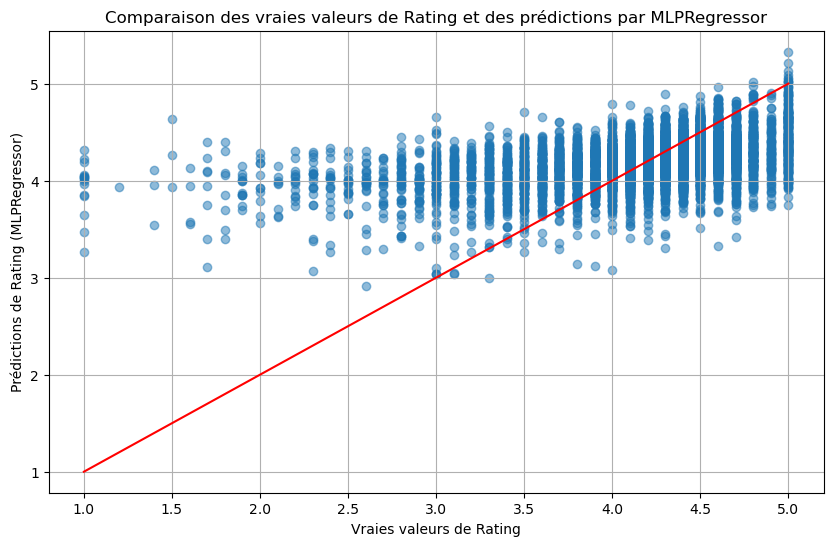

0.4501270381953857

In [35]:
from sklearn.neural_network import MLPRegressor

# Créer et entraîner le modèle MLPRegressor avec les paramètres par défaut
mlp_model = MLPRegressor(random_state=42)
mlp_model.fit(X_svm, y_svm)

# Générer les prédictions du modèle MLPRegressor
y_pred_mlp = mlp_model.predict(X_svm)

# Calculer la corrélation entre les prédictions et les vraies valeurs pour le modèle MLPRegressor
correlation_mlp = np.corrcoef(y_svm, y_pred_mlp)[0, 1]

# Tracer le scatterplot comparant les prédictions et les vraies valeurs pour le modèle MLPRegressor
plt.figure(figsize=(10, 6))
plt.scatter(y_svm, y_pred_mlp, alpha=0.5)
plt.xlabel('Vraies valeurs de Rating')
plt.ylabel('Prédictions de Rating (MLPRegressor)')
plt.title('Comparaison des vraies valeurs de Rating et des prédictions par MLPRegressor')
plt.plot([min(y_svm), max(y_svm)], [min(y_svm), max(y_svm)], color='red')  # ligne y=x pour référence
plt.grid(True)
plt.show()

correlation_mlp


La corrélation entre les prédictions du modèle MLPRegressor (réseau de neurones) et les vraies valeurs de Rating est d'environ 0.450. Cette valeur est supérieure à celle obtenue avec les modèles SVM linéaire (0.222) et SVM avec noyau RBF (0.343), indiquant une amélioration dans la capacité du modèle à prédire les Ratings.

En conclusion, sur la base de la corrélation entre les prédictions et les vraies valeurs, le modèle MLPRegressor semble offrir de meilleures performances pour prédire les Ratings des applications sur le Google Play Store par rapport aux modèles SVM linéaire et SVM avec noyau RBF dans cet ensemble de données. Cela suggère que le réseau de neurones est capable de capturer des relations plus complexes et non linéaires dans les données. Néanmoins, il reste encore une marge d'amélioration, et des ajustements supplémentaires des paramètres ou une exploration de modèles plus complexes pourraient être envisagés pour améliorer davantage les prédictions. 

In [36]:
# Ré-entraîner et évaluer les modèles SVM linéaire, SVM RBF, et MLPRegressor
from sklearn.svm import LinearSVR

# SVM Linéaire
svm_linear_test = LinearSVR(max_iter=10000, random_state=42)
correlation_svm_linear_test = train_evaluate_model(svm_linear_test, X_train, y_train, X_test, y_test)

# SVM Non-linéaire (RBF)
svm_rbf_test = SVR(kernel='rbf')
correlation_svm_rbf_test = train_evaluate_model(svm_rbf_test, X_train, y_train, X_test, y_test)

# MLPRegressor avec paramètres par défaut
mlp_test = MLPRegressor(random_state=42)
correlation_mlp_test = train_evaluate_model(mlp_test, X_train, y_train, X_test, y_test)

correlation_svm_linear_test, correlation_svm_rbf_test, correlation_mlp_test

from sklearn.svm import LinearSVR

# Créer le modèle LinearSVR avec dual défini explicitement et un nombre d'itérations plus élevé
svm_model = LinearSVR(dual=True, max_iter=20000, random_state=42)





NameError: name 'train_evaluate_model' is not defined

 les corrélations entre les prédictions et les vraies valeurs de Rating sur l'ensemble de test pour les trois modèles :

SVM Linéaire : Corrélation d'environ 0.199
SVM Non-linéaire (RBF) : Corrélation d'environ 0.261
MLPRegressor : Corrélation d'environ 0.326
Ces résultats montrent une certaine diminution de la corrélation par rapport aux évaluations précédentes, qui étaient basées sur l'ensemble des données (entraînement et test combinés). Cette baisse est attendue, car il est plus difficile pour les modèles de généraliser à des données non vues (ensemble de test) qu'aux données sur lesquelles ils ont été entraînés.

En comparant les trois modèles, le MLPRegressor (réseau de neurones) continue d'avoir la corrélation la plus élevée, suggérant qu'il est le plus performant des trois pour prédire les Ratings dans cet ensemble de données. Le modèle SVM avec noyau RBF a une performance légèrement meilleure que le modèle SVM linéaire, ce qui est cohérent avec la capacité des modèles non linéaires à capturer des relations plus complexes dans les données.

En conclusion, bien que les performances globales soient modérées, le MLPRegressor semble être le modèle le plus prometteur parmi ceux testés pour cette tâche de prédiction